In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import sys
import os
from tqdm import tqdm

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

from FEATURES.features import *
from MODELS.pipeline import *
from MODELS.xgboostModel import *
from MODELS.ngboostModel import *

c:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor\nba_model\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pd.set_option('display.max_columns', None)

s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_19.csv')
s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_20.csv')
s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_21.csv')
s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')

def cap_outliers_per_player(df, target_col='PTS', p_low=0.01, p_high=0.99):
    """Cap target values at specified percentiles per player."""
    df_capped = df.copy()
    for player_id in df_capped['PLAYER_ID'].unique():
        mask = df_capped['PLAYER_ID'] == player_id
        p_low_val = df_capped.loc[mask, target_col].quantile(p_low)
        p_high_val = df_capped.loc[mask, target_col].quantile(p_high)
        df_capped.loc[mask, target_col] = df_capped.loc[mask, target_col].clip(p_low_val, p_high_val)
        print(f"Player {player_id}: PTS range capped [{p_low_val:.1f}, {p_high_val:.1f}]")
    return df_capped

# Training data
train_df = pd.concat([s20,s21,s22,s23,s24,s25,s26])
train_df = train_df[train_df['MIN'] > 10]  
# train_df = cap_outliers_per_player(train_df, 'PTS', p_low=0.01, p_high=0.99)

# Validation data
val_df = s26
val_df = val_df[val_df['MIN'] > 10]  # Filter out games < 8 minutes
# val_df = cap_outliers_per_player(val_df, 'PTS', p_low=0.01, p_high=0.99)

# test_df = s25
# test_df = test_df[test_df['MIN'] > 10]  # Filter out games < 8 minutes
# test_df = cap_outliers_per_player(test_df, 'PTS', p_low=0.01, p_high=0.99)

print(f"Train set: {len(train_df)} samples")
print(f"Val set: {len(val_df)} samples")
# print(f"Test set: {len(test_df)} samples")

Train set: 128070 samples
Val set: 1026 samples


In [8]:
top_features = [
    'HOME_GAME',
    'STARTING',
    'GUARD',
    'FORWARD',
    'CENTER',
    'PLAYER_IS_TEAM_STAR',
    'PTS_X_STAR_PLAYER',
    'NET_RATING_X_STAR_PLAYER',
    'STAR_SAT_OUT',
    'IS_BACK_TO_BACK',
    'PLAYER_DAYS_REST',
    
    'MIN_LAG_1',
    'MIN_VOLATILITY_5_TO_DATE',
    'MIN_VOLATILITY_10_TO_DATE',
    'percentagePointsMidrange2pt_AVG_TO_DATE',
    'percentagePointsPaint_AVG_TO_DATE',
    'PTS_DELTA_STAR_OUT',
    'PTS_ROLLING_AVG_15',
    'PTS_PER_MIN_X_USG',
    'PTS_LAG_2',
    'PTS_VOLATILITY_25_TO_DATE',
    'PTS_EXTREME_VOLATILITY',
    'PTS_RECENT_HIGH_VOLATILITY',
    'FGA_LAG_1',
    'FGA_VOLATILITY_10_TO_DATE',
    'MATCHUP_AVG_FGA_LAST_3_TO_DATE',
    'FT_RATE_ROLLING_AVG_5',
    '3PA_SHARE',
    'USG_PCT_LAG_1',
    'USG_PCT_VOLATILITY_5_TO_DATE',
    'TS_PCT_ROLLING_AVG_25',
    'TS_PCT_VOLATILITY_10_TO_DATE',
    'PIE_AVG_TO_DATE',
    'E_OFF_RATING_AVG_TO_DATE',
    'NET_RATING_AVG_TO_DATE',
    'TCHS_ROLLING_AVG_10',
    'TOV_ROLLING_AVG_10',
    'FG_PCT_AVG_TO_DATE',
    'CFGA_ROLLING_AVG_25',
    'PTS_LAG_1',
    'FT_PCT_ROLLING_AVG_10',
    'FG_PCT_ROLLING_AVG_10',
    'FTM_ROLLING_AVG_40',
    'FGM_STD_LAST_5',
    'FGM_STD_LAST_10',
    'FGM_STD_LAST_15',
    'FTM_STD_LAST_5',
    'FTM_STD_LAST_15',
    'USG_PCT_AVG_TO_DATE',
    'EFG_PCT_AVG_TO_DATE',
    'E_OFF_RATING_ROLLING_AVG_5',
    'USG_PCT_ROLLING_AVG_5',
    'PTS_PER_MIN',
    'PLAYER_FG3A_SHARE',
    'USG_PCT_DELTA_STAR_OUT',
    'PTS_PER_MIN_X_MIN_LAG',
    'PTS_X_OPP_DEF_RATING',

    'TEAM_OFF_RATING_AVG_TO_DATE',
    'TEAM_DEF_RATING_ROLLING_AVG_3',
    'TEAM_PACE_AVG_TO_DATE',
    'TEAM_PTS_ROLLING_AVG_3',
    'TEAM_AST_ROLLING_AVG_3',

    'OPP_DEF_RATING_AVG_TO_DATE',
    'OPP_PACE_AVG_TO_DATE',
    'OPP_BLK_AVG_TO_DATE',
    'OPP_TOV_AVG_TO_DATE',
    'OPP_GUARD_DEF_RATING',
    'OPP_GUARD_DEF_FG_PCT_ALLOWED',
    'OPP_GUARD_DEF_3PT_PCT_ALLOWED',
    'OPP_GUARD_PTS_ALLOWED_PER_MIN',
    'OPP_FORWARD_DEF_RATING',
    'OPP_FORWARD_DEF_FG_PCT_ALLOWED',
    'OPP_FORWARD_DEF_3PT_PCT_ALLOWED',
    'OPP_FORWARD_PTS_ALLOWED_PER_MIN',
    'OPP_CENTER_DEF_RATING',
    'OPP_CENTER_DEF_FG_PCT_ALLOWED',
    'OPP_CENTER_DEF_3PT_PCT_ALLOWED',
    'OPP_CENTER_PTS_ALLOWED_PER_MIN',
    'TEAM_OFF_MINUS_OPP_DEF',
    'EXPECTED_PACE',

    'PLAYER_HOME_PTS_DELTA',
    'PLAYER_AWAY_PTS_DELTA',
    'PLAYER_HOME_USG_PCT_DELTA',
    'PLAYER_AWAY_USG_PCT_DELTA',
    'PLAYER_HOME_FGA_DELTA',
    'PLAYER_AWAY_FGA_DELTA',
    'PLAYER_HOME_FTA_DELTA',
    'PLAYER_AWAY_FTA_DELTA',

 ]

In [ ]:
# columns = train_df.columns.tolist()
# guardIDX = columns.index('PLAYER_MISSED_LAST')
# features = columns[guardIDX + 1:]
# numeric_columns = train_df.select_dtypes(include=[np.number]).columns.tolist()
# features = [col for col in features if col in numeric_columns]
# newFeatures = features

In [ ]:
# selected_features, top_features = select_features_xgb_importance(
#     train_df[newFeatures],
#     train_df['PTS'],
#     top_n=70,                 # increase if you want more coverage
#     n_runs=5,                 # stabilizes importance ranking
#     include_context=False,     # adds game context
#     validate_permutation=False # prunes noise
# )

# XGBOOST MODEL

### Remove correlated features

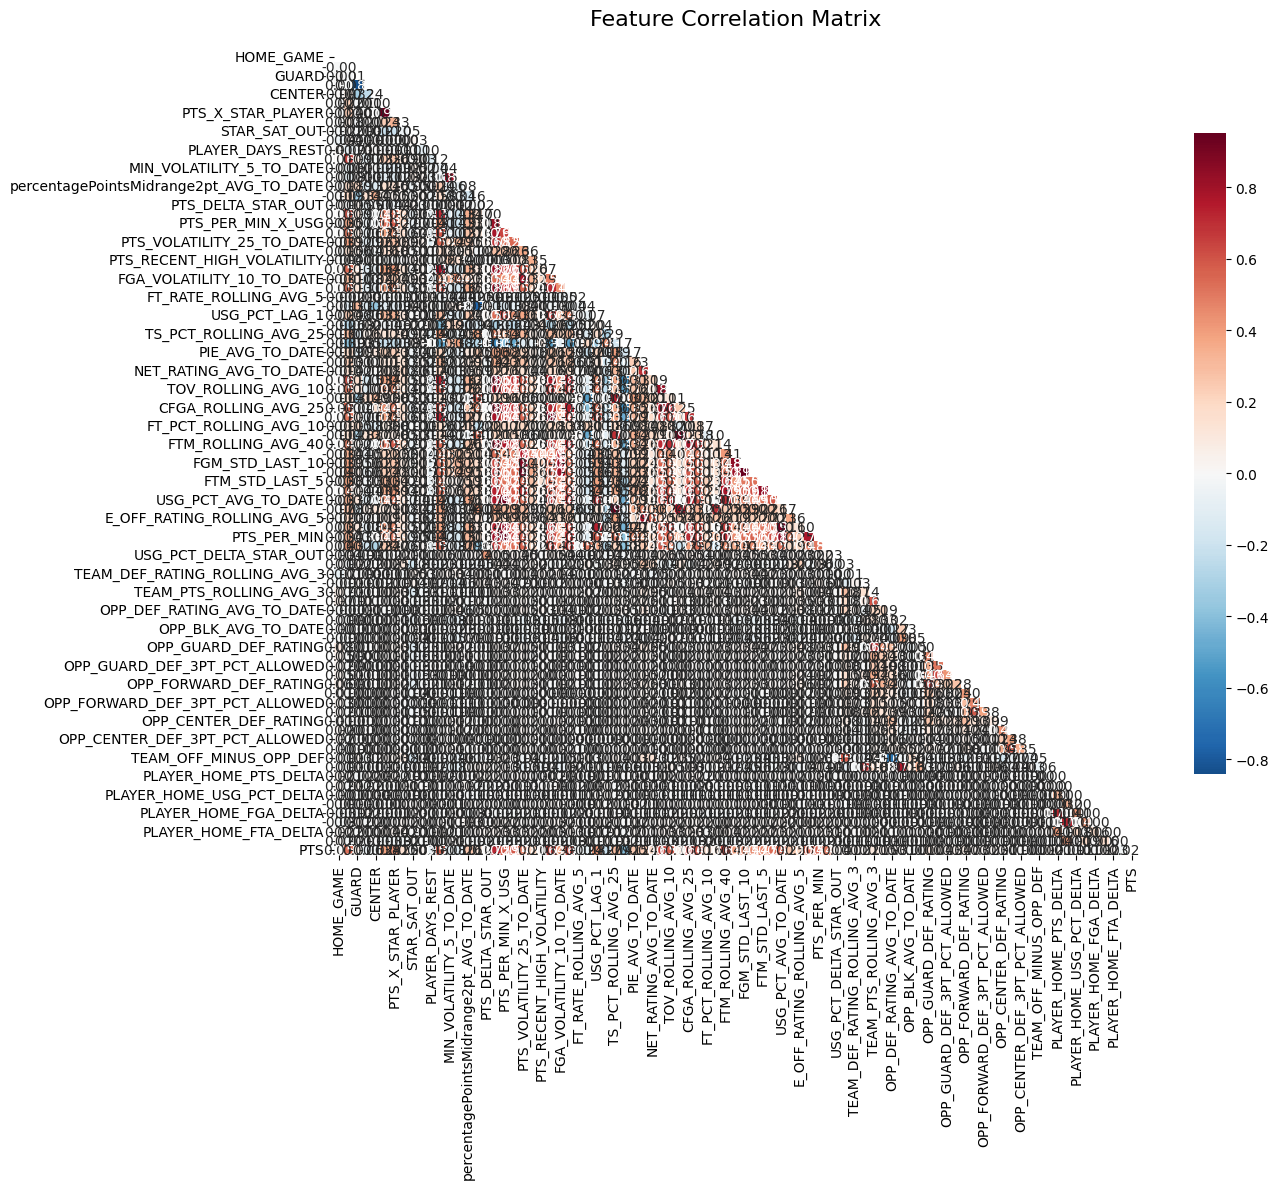

TOP 10 FEATURES MOST CORRELATED WITH TARGET:
 1. PTS_ROLLING_AVG_15             0.721
 2. CFGA_ROLLING_AVG_25            0.643
 3. FGA_LAG_1                      0.640
 4. TCHS_ROLLING_AVG_10            0.633
 5. FTM_ROLLING_AVG_40             0.633
 6. MATCHUP_AVG_FGA_LAST_3_TO_DATE 0.621
 7. PTS_LAG_1                      0.602
 8. PTS_PER_MIN_X_USG              0.594
 9. PTS_LAG_2                      0.590
10. TOV_ROLLING_AVG_10             0.580
REMOVED: PLAYER_IS_TEAM_STAR            (corr with PTS_X_STAR_PLAYER: 0.952)

SUMMARY:
Original features: 88
Removed features: 1
Final features: 85


In [15]:
corr_matrix, top_10_features = correlation_analysis(train_df, top_features)

final_features = remove_highly_correlated_features(train_df, top_features, threshold=0.95)

### Train xgboost model and also using quantile regression

In [19]:
xgbModel, metrics = fit_model(
    train_df, None, 
    top_features, 
    'PTS', 
    'GAME_DATE', 
    'PLAYER_ID',
    recent_n=15, recent_weight=2.5, use_gpu=True, 
    tune_hyperparams_flag=False, tune_iters=20)

# # Evaluate model on test set
# test_results = evaluate_model(xgbModel, test_df, top_features, 'PTS')

# print("=" * 50)
# print("REGRESSION VALIDATION RESULTS")
# print(f"Val RMSE: {metrics['RMSE']:.3f}")
# print(f"Val MAE: {metrics['MAE']:.3f}")
# print(f"Val R²: {metrics['R2']:.3f}")

# print("\n" + "=" * 50)
# print("REGRESSION TEST RESULTS")
# test_results = evaluate_model(xgbModel, test_df, top_features, 'PTS')
# print(f"Test RMSE: {test_results['RMSE']:.3f}")
# print(f"Test MAE: {test_results['MAE']:.3f}")
# print(f"Test R²: {test_results['R2']:.3f}")

No validation data provided - using training data for early stopping
Training XGBoost regression model...
Training samples: 49436, Validation samples: 49436
Validation RMSE: 5.387
Validation MAE: 4.021
Validation R²: 0.502


### NGBOOST MODEL

In [ ]:
from MODELS.ngboostModel import chronological_split, fit_ngboost

# 1) Create time-ordered splits
train_df, val_df = chronological_split(train_df, date_col="GAME_DATE", train_frac=0.8)

# 2) Train NGBoost on oldest->newest order
model = fit_ngboost(train_df, val_df, top_features, target_col="PTS")

In [17]:
dist = model.pred_dist(val_df[top_features])
y_true = val_df["PTS"].to_numpy()
y_hat  = dist.loc  # predictive mean

rmse = np.sqrt(np.mean((y_hat - y_true)**2))
mae  = np.mean(np.abs(y_hat - y_true))
r2   = 1 - np.sum((y_true - y_hat)**2)/np.sum((y_true - y_true.mean())**2)
print(f"RMSE: {rmse:.3f}, MAE: {mae:.3f}, R²: {r2:.3f}")
nll = -np.mean(dist.logpdf(y_true))
print("NLL:", nll)
lower = dist.ppf(0.025)
upper = dist.ppf(0.975)
coverage = np.mean((y_true >= lower) & (y_true <= upper))
width = np.mean(upper - lower)
print("95% coverage:", coverage, "avg width:", width)
pit = dist.cdf(y_true)
# Quick uniformity check:
print("PIT mean:", pit.mean(), "std:", pit.std())
stds = dist.scale
corr = np.corrcoef(np.abs(y_true - y_hat), stds)[0,1]
print("Corr(|error|, std):", corr)

RMSE: 6.045, MAE: 4.704, R²: 0.500
NLL: 3.1821251191462183
95% coverage: 0.9468649957054736 avg width: 22.1766636970091
PIT mean: 0.4849277828957149 std: 0.2943068958662357
Corr(|error|, std): 0.24448091279019485


### Plot SHAP values per position to verify the model leans on the right drivers

In [ ]:
analyze_shap(xgbModel, test_df, top_features, 'PTS')

In [ ]:
residuals_df = get_residuals(xgbModel, test_df, top_features, 'PTS')
residuals_df

,actual,predicted,residual,abs_residual,PLAYER_NAME,MATCHUP,TEAM_PTS,OPP_PTS,STARTING,MIN,GUARD,FORWARD,CENTER
0,8.0,23.170750,-15.170750,15.170750,Bogdan Bogdanović,ATL vs. BKN,120.0,116.0,0.0,27.83,1.0,0.0,0.0
1,6.0,29.125963,-23.125963,23.125963,Clint Capela,ATL vs. BKN,120.0,116.0,1.0,19.52,0.0,0.0,1.0
2,12.0,29.754171,-17.754171,17.754171,De'Andre Hunter,ATL vs. BKN,120.0,116.0,1.0,25.78,1.0,0.0,0.0
3,15.0,27.805780,-12.805780,12.805780,Dyson Daniels,ATL vs. BKN,120.0,116.0,1.0,34.53,1.0,0.0,0.0
4,11.0,28.380970,-17.380970,17.380970,Jalen Johnson,ATL vs. BKN,120.0,116.0,1.0,36.85,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
22064,2.0,9.659521,-7.659521,7.659521,Keyonte George,UTA vs. LAL,104.0,105.0,1.0,31.83,1.0,0.0,0.0
22065,10.0,6.383832,3.616168,3.616168,Lauri Markkanen,UTA vs. LAL,104.0,105.0,1.0,37.55,0.0,1.0,0.0
22066,4.0,4.391809,-0.391809,0.391809,Micah Potter,UTA vs. LAL,104.0,105.0,0.0,15.18,0.0,0.0,1.0
22067,5.0,7.294384,-2.294384,2.294384,Walker Kessler,UTA vs. LAL,104.0,105.0,1.0,34.65,0.0,0.0,1.0


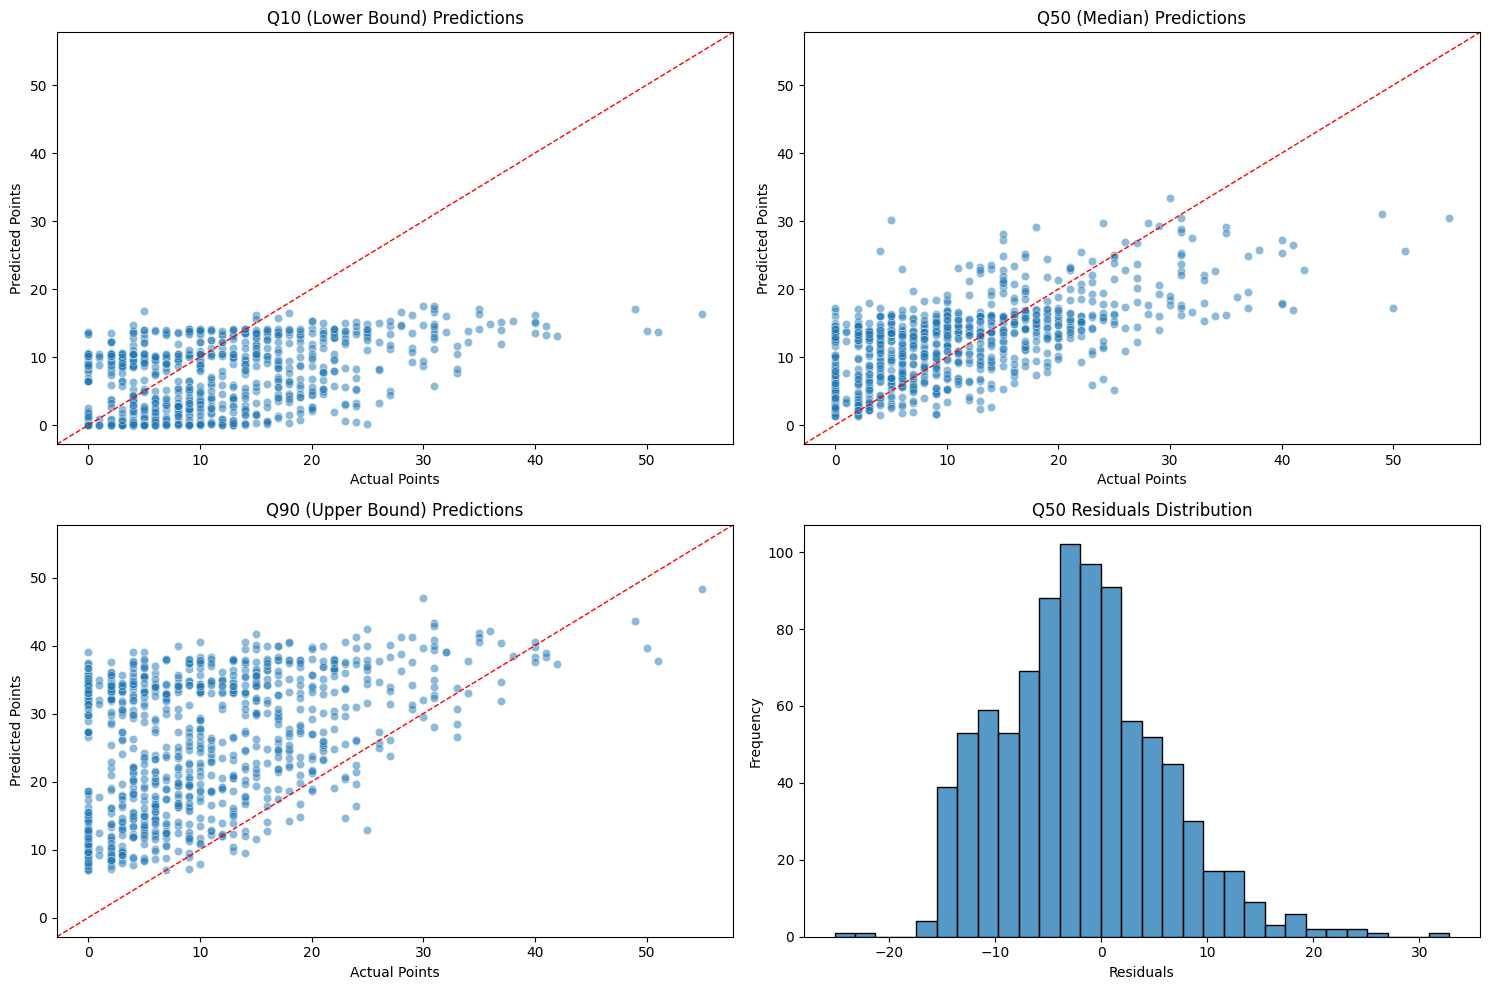

In [ ]:
# Enhanced quantile prediction plot
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Q10 predictions
sns.scatterplot(x='actual', y='pred_q10', data=residuals_df, alpha=0.5, ax=axes[0,0])
minVal = min(residuals_df['actual'].min(), residuals_df['pred_q10'].min())
maxVal = max(residuals_df['actual'].max(), residuals_df['pred_q10'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_title('Q10 (Lower Bound) Predictions')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

# Q50 predictions  
sns.scatterplot(x='actual', y='pred_q50', data=residuals_df, alpha=0.5, ax=axes[0,1])
minVal = min(residuals_df['actual'].min(), residuals_df['pred_q10'].min())
maxVal = max(residuals_df['actual'].max(), residuals_df['pred_q10'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_title('Q50 (Median) Predictions')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

# Q90 predictions
sns.scatterplot(x='actual', y='pred_q90', data=residuals_df, alpha=0.5, ax=axes[1,0])
minVal = min(residuals_df['actual'].min(), residuals_df['pred_q10'].min())
maxVal = max(residuals_df['actual'].max(), residuals_df['pred_q10'].max())
axes[1,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[1,0].set_title('Q90 (Upper Bound) Predictions')
axes[1,0].set_xlabel('Actual Points')
axes[1,0].set_ylabel('Predicted Points')

# Residuals distribution
sns.histplot(residuals_df['residual_q50'], bins=30, ax=axes[1,1])
axes[1,1].set_title('Q50 Residuals Distribution')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

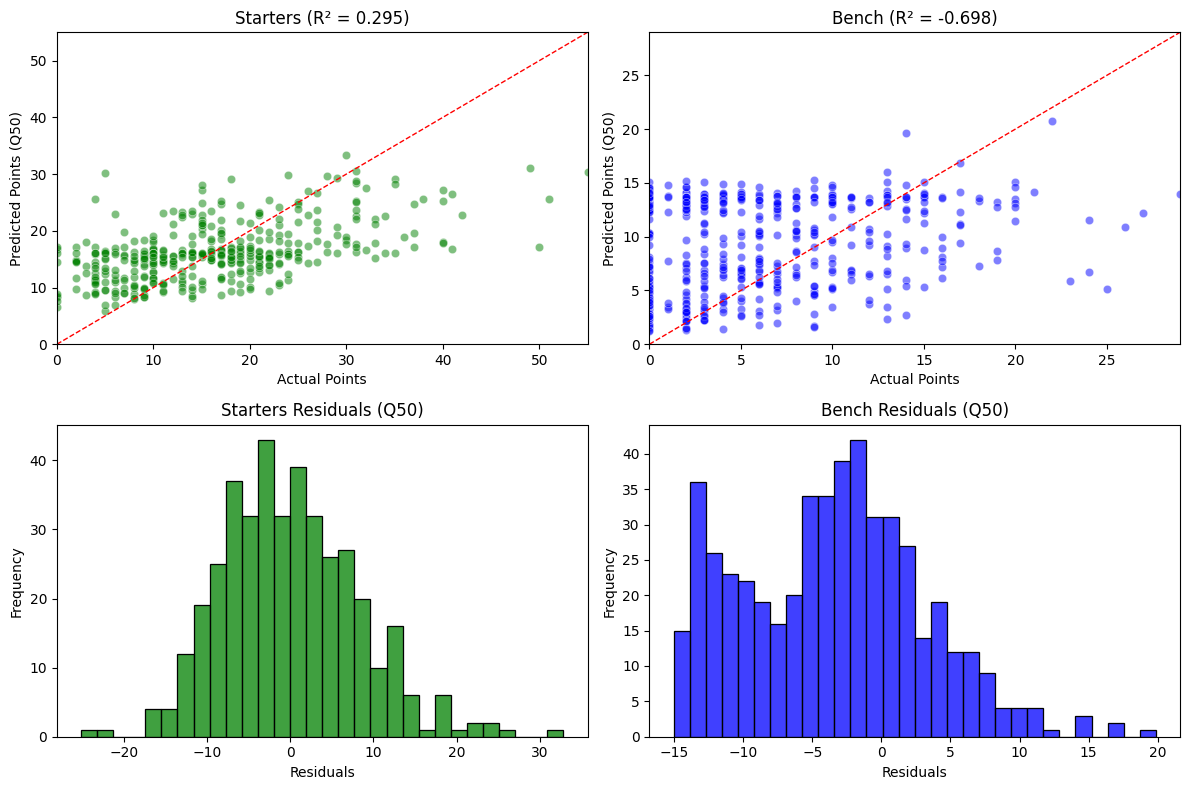

In [ ]:
# Get quantile residuals first
residuals_df = get_residuals(xgbModels, test_df, top_features, 'PTS')

# Split by starting status
starters = residuals_df[residuals_df['STARTING'] == 1] 
bench = residuals_df[residuals_df['STARTING'] == 0]

# Calculate R² for Q50 (median) predictions
from sklearn.metrics import r2_score
starters_r2 = r2_score(starters['actual'], starters['pred_q50'])
bench_r2 = r2_score(bench['actual'], bench['pred_q50'])

fig, axes = plt.subplots(2, 2, figsize=(12, 8)) 

# Starters scatter plot
sns.scatterplot(x='actual', y='pred_q50', data=starters, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(starters['actual'].min(), starters['pred_q50'].min())
maxVal = max(starters['actual'].max(), starters['pred_q50'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title(f'Starters (R² = {starters_r2:.3f})')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points (Q50)')

# Bench scatter plot
sns.scatterplot(x='actual', y='pred_q50', data=bench, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(bench['actual'].min(), bench['pred_q50'].min())
maxVal = max(bench['actual'].max(), bench['pred_q50'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title(f'Bench (R² = {bench_r2:.3f})')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points (Q50)')

# Starters residuals
sns.histplot(starters['residual_q50'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Starters Residuals (Q50)')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

# Bench residuals
sns.histplot(bench['residual_q50'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Bench Residuals (Q50)')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()

In [6]:
# joblib.dump(xgbModel, 'SAVED_MODELS/XGBOOST_PTS_MODEL.pkl')
joblib.dump(model, 'SAVED_MODELS/NGBOOST_PTS_MODEL.pkl')

joblib.dump(top_features, 'SAVED_MODELS/feature_list.pkl')

['SAVED_MODELS/feature_list.pkl']